In [74]:
import numpy as np 
import os
import matplotlib.pyplot as plt
import matplotlib.patches as ps
import torch
import torch_geometric
import pandas as pd

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.tri as mtri

from torch_geometric.data import Data
from torch_geometric.data import HeteroData
from scipy.optimize import curve_fit
from sm import NeuralNet

print(torch.version.cuda)
print(torch.__version__)
print(torch_geometric.__version__)

11.8
2.7.0+cu118
2.6.1


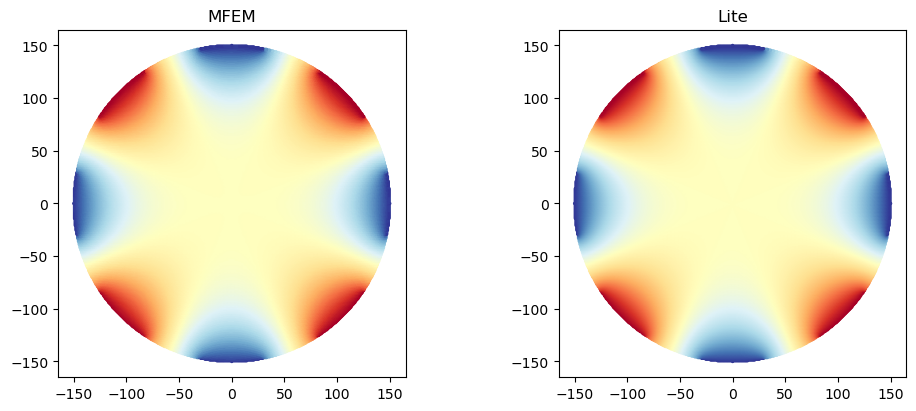

In [72]:
mfem = pd.read_csv("/home/hd/hd_hd/hd_gy283/kmc_project/mfem_xy.csv")
lite = pd.read_csv("/home/hd/hd_hd/hd_gy283/kmc_project/lite_xy.csv")  # from your lightweight solver

fig, ax = plt.subplots(1,2, figsize=(10,4), constrained_layout=True)

ax[0].scatter(mfem.x, mfem.y, c=mfem.phi, cmap="RdYlBu_r", s=2)
ax[0].set_title("MFEM"); ax[0].set_aspect('equal')

ax[1].scatter(lite.x, lite.y, c=lite.phi, cmap="RdYlBu_r", s=2)
ax[1].set_title("Lite"); ax[1].set_aspect('equal')

plt.show()

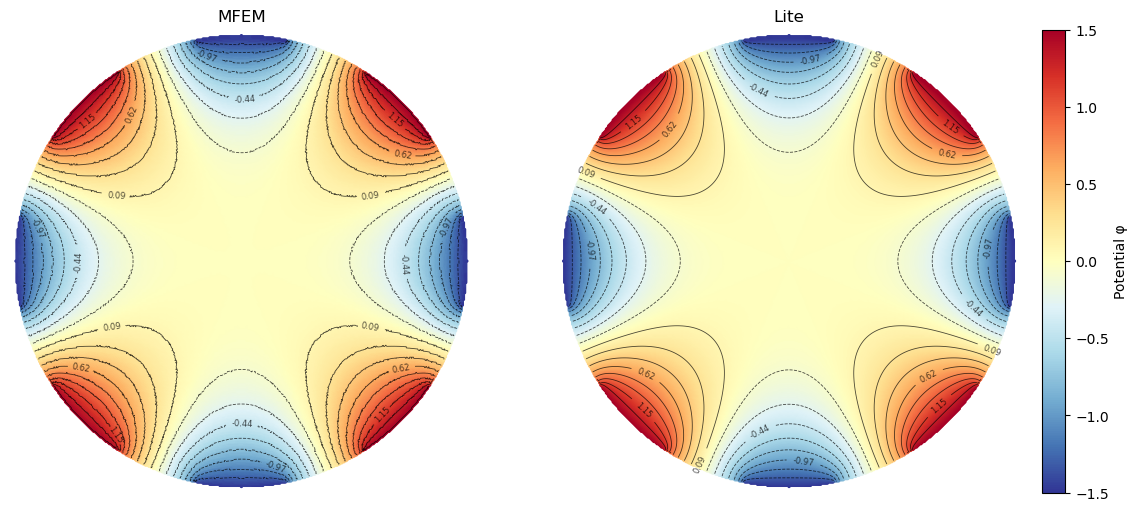

In [90]:
# Choose common contour levels so both panels are comparable
phi_min = min(mfem.phi.min(), lite.phi.min())
phi_max = max(mfem.phi.max(), lite.phi.max())
levels = np.linspace(phi_min, phi_max, 18)  # tweak number of lines here

R = mfem.x.max()

pad = 4.0

fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for a in ax:
    a.set_xlim(-R-pad, R+pad)
    a.set_ylim(-R-pad, R+pad)
    a.set_xticks([])
    a.set_yticks([])
    a.spines[:].set_visible(False)

# --- MFEM ---
ax[0].scatter(mfem.x, mfem.y, c=mfem.phi, cmap="RdYlBu_r", s=2, zorder=1)
tri_m = mtri.Triangulation(mfem.x.values, mfem.y.values)
cs_m = ax[0].tricontour(tri_m, mfem.phi.values, levels=levels, colors='k',
                        linewidths=0.6, alpha=0.7, zorder=2)
# Optional labels on a subset of lines (comment out if cluttered)
ax[0].clabel(cs_m, cs_m.levels[::3], fmt="%.2f", fontsize=6, inline=True)
ax[0].set_title("MFEM")
ax[0].set_aspect('equal')

# --- Lite ---
ax[1].scatter(lite.x, lite.y, c=lite.phi, cmap="RdYlBu_r", s=2, zorder=1)
tri_l = mtri.Triangulation(lite.x.values, lite.y.values)
cs_l = ax[1].tricontour(tri_l, lite.phi.values, levels=levels, colors='k',
                        linewidths=0.6, alpha=0.7, zorder=2)
ax[1].clabel(cs_l, cs_l.levels[::3], fmt="%.2f", fontsize=6, inline=True)
ax[1].set_title("Lite")
ax[1].set_aspect('equal')

# Optional: a single shared colorbar
cbar = fig.colorbar(ax[1].collections[0], ax=ax, orientation='vertical', fraction=0.025, pad=0.02)
cbar.set_label("Potential φ")

plt.show()

In [30]:
import pandas as pd
import numpy as np

# Load CSVs: columns x,y,phi
mfem = pd.read_csv("/home/hd/hd_hd/hd_gy283/kmc_project/mfem_xy.csv")
lite = pd.read_csv("/home/hd/hd_hd/hd_gy283/kmc_project/lite_xy.csv")

# Join on (x,y). Assumes identical raster; if not, this will shrink to intersection.
df = mfem.merge(lite, on=["x","y"], suffixes=("_mfem","_lite"))
phi_m = df["phi_mfem"].to_numpy()
phi_l = df["phi_lite"].to_numpy()

# ---------- Plain (unaligned) errors ----------
diff = phi_m - phi_l
rmse = np.sqrt(np.mean(diff**2))
mae  = np.mean(np.abs(diff))
linf = np.max(np.abs(diff))
rng  = np.max(phi_m) - np.min(phi_m)
rel_rmse_pct = 100.0 * rmse / (rng if rng != 0 else 1.0)

print("=== Unaligned errors ===")
print(f"RMSE           : {rmse:.6g}")
print(f"MAE            : {mae:.6g}")
print(f"Linf (max abs) : {linf:.6g}")
print(f"Relative RMSE  : {rel_rmse_pct:.3f}%  (normalized by MFEM range)")

# ---------- Offset-only alignment (β) ----------
beta = np.mean(phi_m - phi_l)  # least-squares offset
diff_off = phi_m - (phi_l + beta)
rmse_off = np.sqrt(np.mean(diff_off**2))
linf_off = np.max(np.abs(diff_off))
mae_off  = np.mean(np.abs(diff_off))
rel_rmse_off = 100.0 * rmse_off / (rng if rng != 0 else 1.0)

print("\n=== Offset-aligned (φ_m ≈ φ_l + β) ===")
print(f"β (offset)     : {beta:.6g}")
print(f"RMSE           : {rmse_off:.6g}")
print(f"MAE            : {mae_off:.6g}")
print(f"Linf (max abs) : {linf_off:.6g}")
print(f"Relative RMSE  : {rel_rmse_off:.3f}%")

# ---------- Affine alignment (α, β) ----------
A = np.vstack([phi_l, np.ones_like(phi_l)]).T
alpha, beta_aff = np.linalg.lstsq(A, phi_m, rcond=None)[0]
diff_aff = phi_m - (alpha * phi_l + beta_aff)
rmse_aff = np.sqrt(np.mean(diff_aff**2))
linf_aff = np.max(np.abs(diff_aff))
mae_aff  = np.mean(np.abs(diff_aff))
rel_rmse_aff = 100.0 * rmse_aff / (rng if rng != 0 else 1.0)

print("\n=== Affine-aligned (φ_m ≈ α φ_l + β) ===")
print(f"α (scale)      : {alpha:.6g}")
print(f"β (offset)     : {beta_aff:.6g}")
print(f"RMSE           : {rmse_aff:.6g}")
print(f"MAE            : {mae_aff:.6g}")
print(f"Linf (max abs) : {linf_aff:.6g}")
print(f"Relative RMSE  : {rel_rmse_aff:.3f}%")

# ---------- Boundary-only error (diagnostic) ----------
# Grab points near the circle: r ≈ R
r = np.hypot(df["x"].to_numpy(), df["y"].to_numpy())
R = np.max(r)  # should be ~ your radius
mask_bdr = np.isclose(r, R, rtol=0, atol=R/ max(50, int(np.sqrt(len(r)))))  # a thin ring
if mask_bdr.any():
    bd = diff_aff[mask_bdr]
    print("\n=== Boundary (affine-aligned) ===")
    print(f"Boundary RMSE  : {np.sqrt(np.mean(bd**2)):.6g}")
    print(f"Boundary Linf  : {np.max(np.abs(bd)):.6g}")
else:
    print("\n[warn] Could not identify boundary ring in the raster.")

# ---------- Optional: write a difference map CSV ----------
out = df[["x","y"]].copy()
out["diff_aff"] = diff_aff  # best-aligned residual
out.to_csv("diff_aff_xy.csv", index=False)
print("\nWrote diff_aff_xy.csv (x,y,residual after affine alignment).")


=== Unaligned errors ===
RMSE           : 0.00921109
MAE            : 0.0056244
Linf (max abs) : 0.28823
Relative RMSE  : 0.307%  (normalized by MFEM range)

=== Offset-aligned (φ_m ≈ φ_l + β) ===
β (offset)     : -0.000141018
RMSE           : 0.00921001
MAE            : 0.00562031
Linf (max abs) : 0.288089
Relative RMSE  : 0.307%

=== Affine-aligned (φ_m ≈ α φ_l + β) ===
α (scale)      : 1.00598
β (offset)     : -0.000142801
RMSE           : 0.00868054
MAE            : 0.00538159
Linf (max abs) : 0.280841
Relative RMSE  : 0.289%

=== Boundary (affine-aligned) ===
Boundary RMSE  : 0.0216053
Boundary Linf  : 0.120662

Wrote diff_aff_xy.csv (x,y,residual after affine alignment).


['current', 'currentStd', 'sem', 'control', 'inputIdx', 'outputIdx']


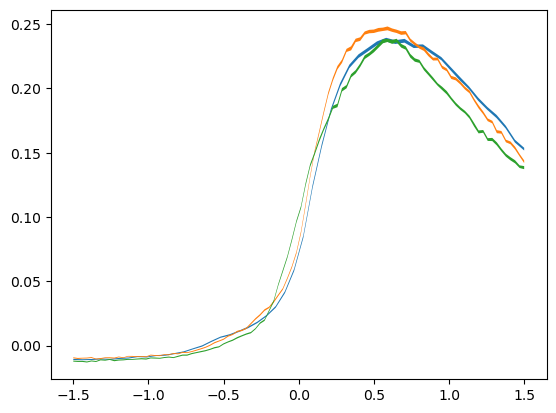

In [64]:
data_0 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/vMB_sim_444.npz")
data_1 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/vMB_sim_111.npz")
data_2 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/vMB_sim_222.npz")
print(data_1.files)
x_100 = np.linspace(-1.5, 1.5, 100)
x_50 = np.linspace(-1.5, 1.5, 50)
plt.fill_between(x_50, data_0["current"]-data_0["sem"], data_0["current"]+data_0["sem"])
plt.fill_between(x_100, data_1["current"]-data_1["sem"], data_1["current"]+data_1["sem"])
plt.fill_between(x_100, data_2["current"]-data_2["sem"], data_2["current"]+data_2["sem"])

13


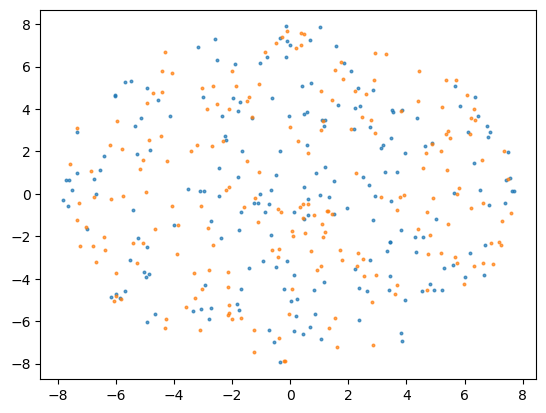

In [59]:
from sm_with_pos import SMPos
from train_sm import create_data_loaders

idx = np.random.randint(0, 25)
dummy_data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/pos_batches_1e6/batch_{idx}.npz")
print(idx)
num_batches = 100
for i in range(2):
    plt.scatter(*dummy_data["acc_xy"][i].T, s=3.5, alpha=.7)

['inputIdx', 'outputIdx', 'currents', 'inputs', 'sampleStd', 'sem', 'acc_xy', 'don_xy']
(100,)
(100, 200, 2)


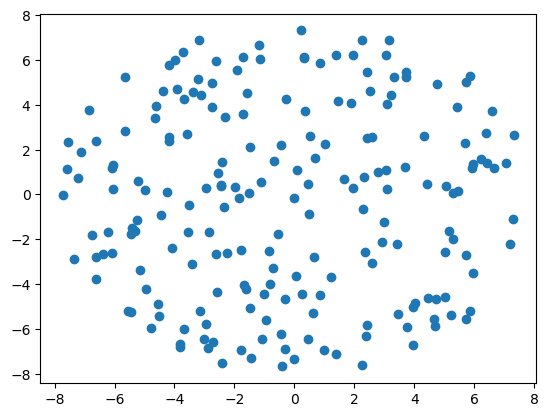

In [27]:
sim = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/pos_batches_1e7/batch_0.npz")
print(sim.files)
print(sim["currents"].shape)
print(sim["acc_xy"].shape)
idx = np.random.randint(0, 100)
plt.scatter(*sim["acc_xy"][idx].T)

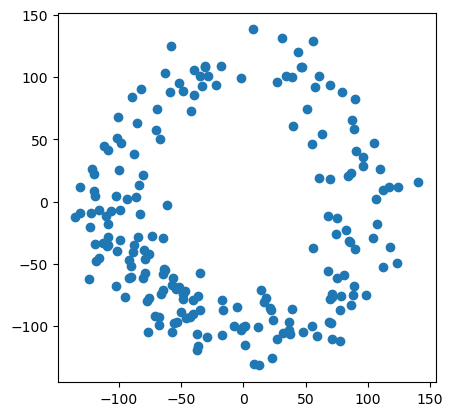

In [4]:
pos = np.loadtxt("/gpfs/bwfor/work/ws/hd_gy283-my_data/data_vMB/vMB_configs/acceptors.txt")
fig, ax = plt.subplots()
ax.scatter(*pos.T)
ax.set_aspect("equal")

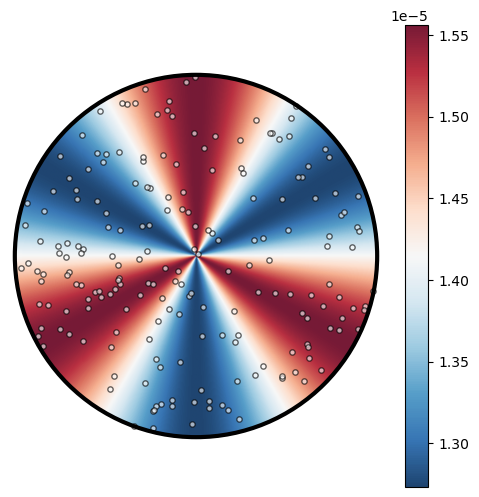

In [153]:
def sample_anisotropic(N, R=150.0, m=3, a=0.6, phi=0.0, seed=None):
    """
    Sample N dopants in a disk of radius R with m-fold angular anisotropy.
    a in [0,1): 0=uniform, ->1 strong anisotropy. phi rotates the pattern.
    """
    rng = np.random.default_rng(seed)
    pts = []
    # accept–reject on theta with weight w = 1 + a*cos(m*(theta - phi))
    while len(pts) < N:
        # uniform-in-disk radius
        r = R * np.sqrt(rng.random())
        theta = rng.random() * 2*np.pi
        w = 1 + a*np.cos(m*(theta - phi))
        if rng.random() < w/(1+a):         # normalized acceptance
            pts.append((r*np.cos(theta), r*np.sin(theta)))
    return np.array(pts)

def anisotropic_pdf(R, m, a, phi_deg, n=400):

    phi = np.deg2rad(phi_deg)   

    x = np.linspace(-R, R, n)
    y = np.linspace(-R, R, n)
    xx, yy = np.meshgrid(x, y)

    rr = np.hypot(xx, yy)
    theta = np.arctan2(yy, xx)

    f = (1 + a*np.cos(m*(theta - phi))) / (np.pi * R**2)
    f = np.where(rr <= R, f, np.nan)

    return f
phi_deg = 90
a = 0.1
m = 3
f = anisotropic_pdf(R=150, m=m, a=a, phi_deg=phi_deg)

sample = sample_anisotropic(N=200, m=m, a=a, phi=np.deg2rad(phi_deg))
np.savetxt("/home/hd/hd_hd/hd_gy283/kmc_project/configs/radial_distribution.txt", sample, fmt="%.6f", delimiter="\t")
R = 150
fig, ax = plt.subplots(figsize=(6,6))

ax.set_aspect("equal", adjustable="box")
im = ax.imshow(f, extent=(-R, R, -R, R), origin="lower", cmap="RdBu_r", alpha=0.9)
ax.scatter(*sample.T, s=14.5, edgecolor="k", facecolor="w", alpha=0.6, zorder=3)
ax.add_patch(ps.Circle(xy=(0,0), radius=R, fill=None, linewidth=3, zorder=4))

ax.spines[:].set_visible(False)
pad = 4
ax.set_xlim(-R-pad, R+pad)
ax.set_ylim(-R-pad, R+pad)
ax.set_xticks([])
ax.set_yticks([])

fig.colorbar(im)

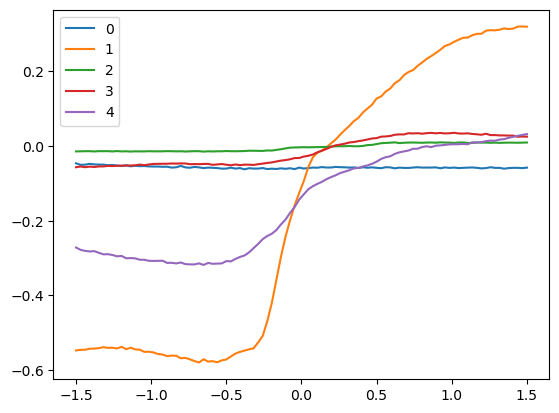

In [156]:
x = np.linspace(-1.5, 1.5, 100)
for i in range(5):
    data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/sim_radial_distribution_{i}.npz")
    plt.plot(x, data["current"], label=i)
    plt.legend()

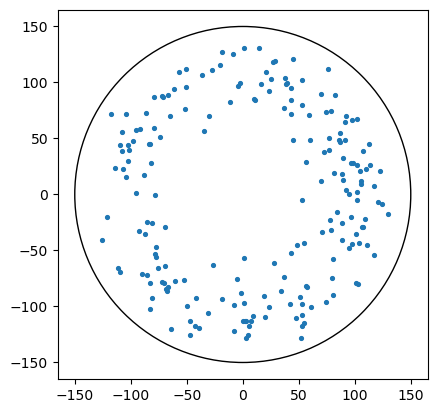

In [12]:
acc = np.loadtxt("/home/hd/hd_hd/hd_gy283/kmc_project/cpp_vMB.txt")
fig, ax = plt.subplots()
ax.scatter(*acc.T, s=7.5)
ax.add_patch(ps.Circle(xy=(0,0), radius=150.0, fill=None))
ax.set_aspect("equal")

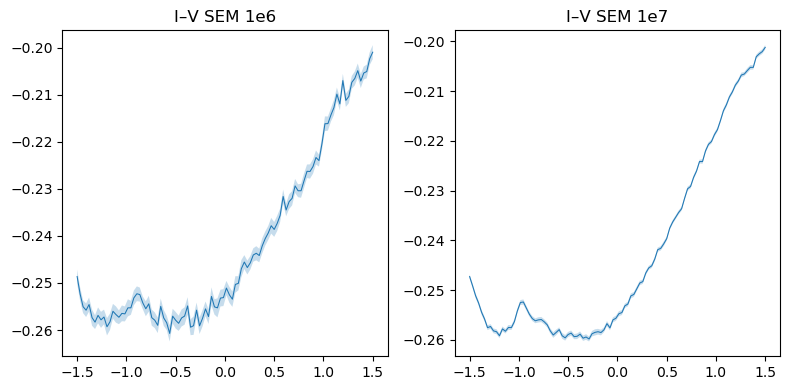

In [4]:
test_data_1e6 = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/sim_vMB_test.npz")
test_data_1e7 = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/sim_vMB_test_1e7.npz")

I_1e7 = test_data_1e7["current"]
I_sem_1e7 = test_data_1e7["sem"]

I_1e6 = test_data_1e6["current"]
I_sem_1e6 = test_data_1e6["sem"]

N = 100
vs = np.linspace(-1.5, 1.5, N)
fig, ax = plt.subplots(ncols=2, figsize=(8, 4))

for a in ax:
    a.set_aspect('auto')

#ax[0].errorbar(vs, I, yerr=I_sem, fmt='o', markersize=1.5, capsize=3, alpha=.7)
#ax[0].plot(vs, I, lw=1., linestyle="dashed", zorder=3)
#ax[0].set_title("I–V with uncertainty (SEM)")

ax[0].plot(vs, I_1e6, lw=0.75)
ax[0].fill_between(vs, I_1e6 - I_sem_1e6, I_1e6 + I_sem_1e6, alpha=0.25)
ax[0].set_title("I–V SEM 1e6")

ax[1].plot(vs, I_1e7, lw=0.75)
ax[1].fill_between(vs, I_1e7 - I_sem_1e7, I_1e7 + I_sem_1e7, alpha=0.25)
ax[1].set_title("I–V SEM 1e7")

plt.tight_layout()

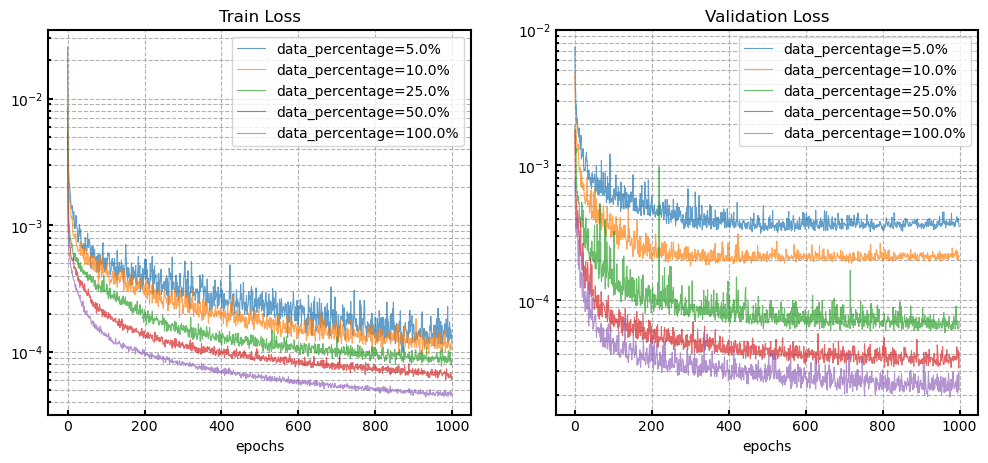

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sm import NeuralNet

num_batches_list = [10, 20, 50, 100, 200]

fig, ax = plt.subplots(ncols=2, figsize=(12, 5))
norm = Normalize(vmin=min(num_batches_list), vmax=max(num_batches_list))
cmap = plt.get_cmap("jet")

for idx, i in enumerate(num_batches_list):
    checkpoint = torch.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/sm_vMB_MCSteps=1e7_num_batches={i}.pth", map_location=torch.device("cpu"), weights_only=False)
    model = NeuralNet(in_features=7, out_features=1, hidden_dim=checkpoint["args"]["hd"], num_layers=checkpoint["args"]["num_layers"])
    # Restore model parameters
    model.load_state_dict(checkpoint["model_state_dict"])
    
    # Restore training arguments (if needed)
    saved_args = checkpoint["args"]
    
    # Restore losses
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    plot_kwargs = {
        "lw": .8,
        "alpha": 0.7
    }

    for a in ax:
        a.spines[:].set_linewidth(1.5)
    
    ax[0].plot(train_losses, **plot_kwargs, label=f"data_percentage={100 * i*1000 / 200000}%")
    ax[0].set_yscale("log")
    ax[0].tick_params(which="both", direction="in", width=1.5)
    ax[0].legend()
    ax[0].set_aspect("auto")
    ax[0].set_xlabel("epochs")
    ax[0].grid(True, which="both", linestyle="dashed")#
    ax[0].set_title("Train Loss")
    
    ax[1].plot(val_losses, **plot_kwargs, label=f"data_percentage={100 * i*1000 / 200000}%")
    ax[1].set_yscale("log")
    ax[1].tick_params(which="both", direction="in", width=1.5)
    ax[1].legend()
    ax[1].set_aspect("auto")
    ax[1].set_xlabel("epochs")
    ax[1].grid(True, which="both", linestyle="dashed")
    ax[1].set_title("Validation Loss")

In [2]:
from tune_sm import find_control_voltages_1D

def target_function(t: torch.Tensor):
        N = t.shape[0]
        return 0.25*torch.sin(2*t)
    
min = -1.5
max = 1.5
N = 100
x = torch.linspace(min, max, N)
target = target_function(x).unsqueeze(1)

state_dict = torch.load(f="/home/hd/hd_hd/hd_gy283/kmc_project/models/SM_1e6_vonMises_beta_0.pth", map_location=torch.device("cpu"))
#print(state_dict)

in_features = 7
out_features = 1
hidden_dim = 90
num_layers = 10

model = NeuralNet(in_features=in_features, out_features=out_features, hidden_dim=hidden_dim, num_layers=num_layers)
model.load_state_dict(state_dict=state_dict)

input_idx = 0
study = find_control_voltages_1D(model=model, target=target, N=N, min_voltage=min, max_voltage=max, input_idx=input_idx, n_startup_trials=1000, n_trials=2_000, PRINT_EVERY=1000)

print("Best value:", study.best_value)
print("Best params:", study.best_params)  

4.4.0
cuda


TypeError: find_control_voltages_1D() got an unexpected keyword argument 'min_voltage'

v_list=[0.9087684029521395, 1.081264180783419, -0.31040417077013527, 1.3745292029787675, 0.01781493815272761, -0.29835713274305525]
noise=[-0.02607364 -0.04372324  0.07223905  0.05006392  0.07181847 -0.10867331]
c_v with noise=tensor([ 0.9088,  1.0813, -0.3104,  1.3745,  0.0178, -0.2984])


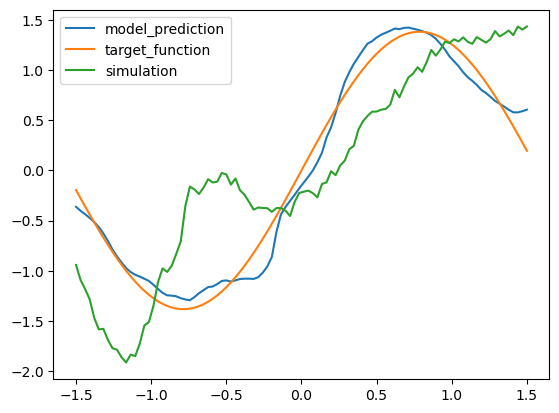

In [63]:
v_list = []
for k in study.best_params.keys():
    v_list.append(study.best_params[k])
print(f"v_list={v_list}")
v_array = np.array(v_list)
noise = np.random.normal(loc=0.0, scale=0.05, size=v_array.shape)
print(f"noise={noise}")

c_tensor = torch.tensor(v_list, dtype=torch.float32).expand(N, -1)
print(f"c_v with noise={c_tensor[0,:]}")
c_tensor_left = c_tensor[:, :input_idx]
c_tensor_right = c_tensor[:, input_idx:]
v_tensor = torch.linspace(-1.5, 1.5, N).unsqueeze(1)
input_tensor = torch.cat([c_tensor_left, v_tensor, c_tensor_right], dim=1)

y = model(input_tensor).detach().cpu()
x = torch.linspace(-1.5, 1.5, N)

y_norm = (y - y.mean()) / y.std()
target_norm = (target_function(x) - target_function(x).mean()) / target_function(x).std()

data = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/simulated_curve_vonMises_beta_no_noise.npz")
current_norm = (data["current"] - data["current"].mean()) / data["current"].std()
plt.plot(x, y_norm, label="model_prediction")
plt.plot(x, target_norm, label="target_function")
plt.plot(x, current_norm, label="simulation")
plt.legend()

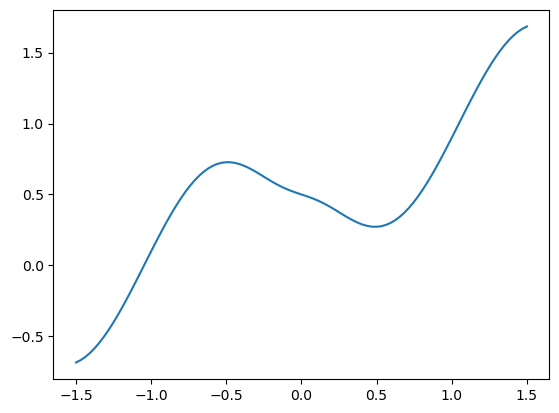

In [26]:
def test_target(t: torch.Tensor):
    N = t.shape[0]
    return -0.7*torch.sin(3*t) + torch.sigmoid(7*t)

x = torch.linspace(-1.5, 1.5, 100)

out = test_target(x)

plt.plot(x, out)

## 1.) Uniform Distribution

torch.Size([100, 1])


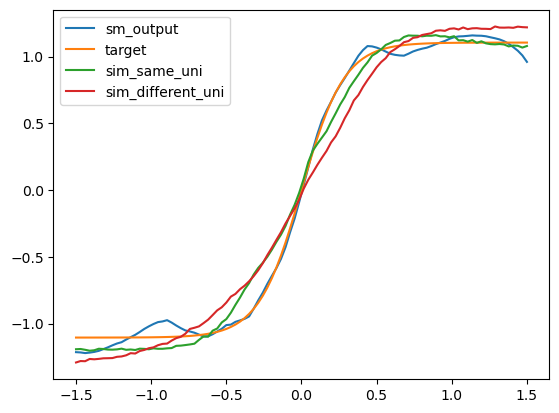

In [24]:
best_params = {'x_0': -1.3521200735168495, 'x_1': -1.4902781359421968, 'x_2': 1.1775679593714892, 'x_3': 1.4850596665151372, 'x_4': -0.5546491202122263, 'x_5': -0.5566989497370551}

v_list = []
for k in best_params.keys():
    v_list.append(best_params[k])

N = 100
c_volts = torch.tensor(v_list, dtype=torch.float32)
volts = torch.linspace(-1.5, 1.5, N, dtype=torch.float32).unsqueeze(1)
print(volts.shape)

input_tensor = c_volts.expand(N, -1)
input_tensor = torch.cat((input_tensor[:, :1], volts, input_tensor[:, 1:]), dim=1)

state_dict = torch.load(f="/home/hd/hd_hd/hd_gy283/kmc_project/models/SM_100k_0.pth", map_location=torch.device("cpu"))

in_features = 7
out_features = 1
hidden_dim = 90
num_layers = 7

model = NeuralNet(in_features=in_features, out_features=out_features, hidden_dim=hidden_dim, num_layers=num_layers)
model.load_state_dict(state_dict=state_dict)
model.eval()

y = model(input_tensor).detach().cpu()

def target_function(t: torch.Tensor):
        N = t.shape[0]
        return torch.sigmoid(7*t)
x = torch.linspace(-1.5, 1.5, N)

target = target_function(x)
target_norm = (target - target.mean()) / target.std()

data_0 = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/simulated_curve_uni.npz")
current_norm_0 = (data_0["current"] - data_0["current"].mean()) / data_0["current"].std()

data_1 = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/simulated_curve_different_uni.npz")
current_norm_1 = (data_1["current"] - data_1["current"].mean()) / data_1["current"].std()

y_norm = (y - y.mean()) / y.std()
plt.plot(x, y_norm, label="sm_output")
plt.plot(x, target_norm, label="target")
plt.plot(x, current_norm_0, label="sim_same_uni")
plt.plot(x, current_norm_1, label="sim_different_uni")
plt.legend()

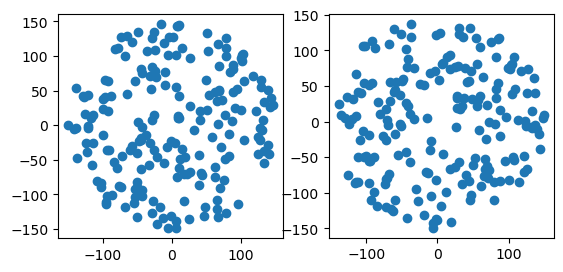

In [22]:
acc_1 = np.loadtxt("/home/hd/hd_hd/hd_gy283/kmc_project/configs/acc_0.txt")
acc_2 = np.loadtxt("/home/hd/hd_hd/hd_gy283/kmc_project/data/sm_batches/acceptors.txt")

fig, ax = plt.subplots(1, 2)

ax[0].set_aspect("equal")
ax[1].set_aspect("equal")

ax[0].scatter(*acc_1.T)
ax[1].scatter(*acc_2.T)

## 2.) von Mises and Beta

torch.Size([100, 1])
tensor([[-1.5000, -1.3362,  1.4418, -1.1590, -1.4984, -0.7704, -0.5946],
        [-1.4697, -1.3362,  1.4418, -1.1590, -1.4984, -0.7704, -0.5946],
        [-1.4394, -1.3362,  1.4418, -1.1590, -1.4984, -0.7704, -0.5946],
        [-1.4091, -1.3362,  1.4418, -1.1590, -1.4984, -0.7704, -0.5946],
        [-1.3788, -1.3362,  1.4418, -1.1590, -1.4984, -0.7704, -0.5946]])


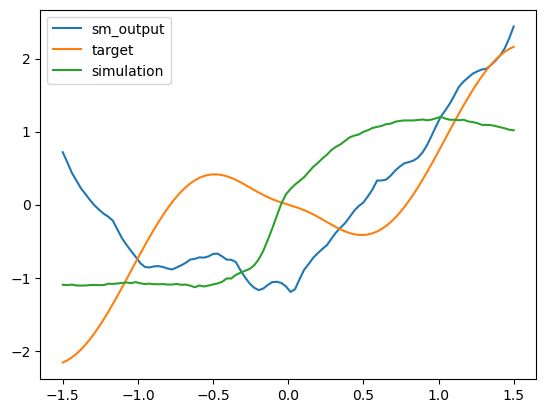

In [9]:
best_params = {'x_0': -1.3361728511258262, 'x_1': 1.441842973713247, 'x_2': -1.1589845724078525, 'x_3': -1.4984348328318093, 'x_4': -0.770405593405382, 'x_5': -0.5946394889964599}
v_list = []
for k in best_params.keys():
    v_list.append(best_params[k])

N = 100
c_volts = torch.tensor(v_list, dtype=torch.float32)
volts = torch.linspace(-1.5, 1.5, N, dtype=torch.float32).unsqueeze(1)
print(volts.shape)

input_tensor = c_volts.expand(N, -1)
input_tensor = torch.cat((volts, input_tensor), dim=1)
print(input_tensor[:5, :])
state_dict = torch.load(f="/home/hd/hd_hd/hd_gy283/kmc_project/models/SM_1e6_vonMises_beta_0.pth", map_location=torch.device("cpu"))

in_features = 7
out_features = 1
hidden_dim = 90
num_layers = 10

model = NeuralNet(in_features=in_features, out_features=out_features, hidden_dim=hidden_dim, num_layers=num_layers)
model.load_state_dict(state_dict=state_dict)
model.eval()

y = model(input_tensor).detach().cpu()

def target_function(t: torch.Tensor):
        N = t.shape[0]
        return -0.7*torch.sin(3*t) + torch.sigmoid(7*t)
x = torch.linspace(-1.5, 1.5, N)

data = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/simulated_curve_vonMises_beta.npz")
current_norm = (data["current"] - data["current"].mean()) / data["current"].std()

target = target_function(x)
target_norm = (target - target.mean()) / target.std()
y_norm = (y - y.mean()) / y.std()
plt.plot(x, y_norm, label="sm_output")
plt.plot(x, target_norm, label="target")
plt.plot(x, current_norm, label="simulation")
plt.legend()

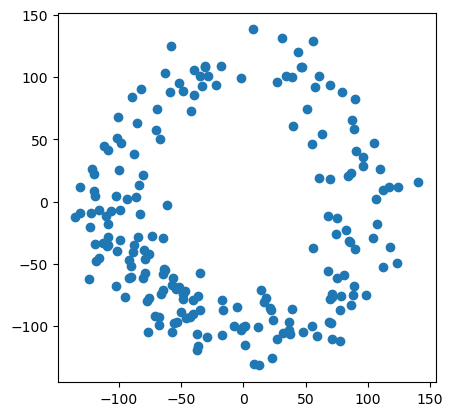

In [5]:
acc_0 = np.loadtxt("/home/hd/hd_hd/hd_gy283/kmc_project/data/sm_batches_1e6_vonMises_beta/acceptors.txt")
fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.scatter(*acc_0.T)

In [ ]:
def target_function(x):

    target = 1 / (1 + np.exp(-4*x)) + -0.5*np.sin(4*x)

    return target

x = np.linspace(-1.5, 1.5, 100)

plt.plot(x, target_function(x))

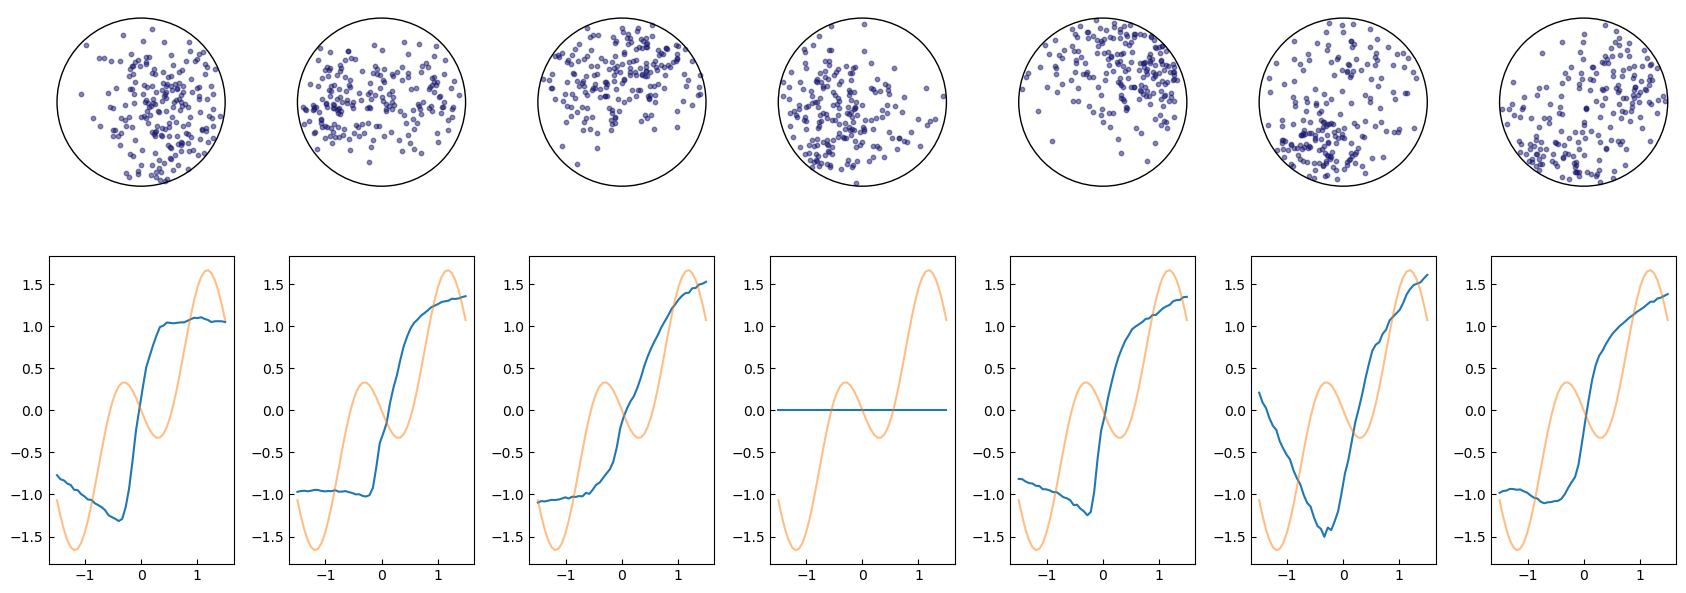

In [53]:
trials = 7
circle_kwargs = {
    "xy": (0,0),
    "radius": 150 + 2.5,
    "fill": None
}

x = np.linspace(-1.5, 1.5, 50)
fig, axs = plt.subplots(nrows=2, ncols=trials, figsize=(3*trials, 8))
for i in range(trials):
    pos = np.loadtxt(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/find_node_dist_test/trial_{i}/acceptors_trial={i}_sample=0.txt")
    data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/find_node_dist_test/trial_{i}/curve_trial={i}_sample=0.npz")
    curve = (data["current"] - data["current"].mean()) / (data["current"].std() + 1e-8)
    target = target_function(x)
    target = (target - target.mean()) / (target.std() + 1e-8)
    axs[0, i].set_aspect("equal")
    axs[0, i].scatter(*pos.T, s=10, alpha=.5, c="midnightblue")
    axs[0, i].add_patch(ps.Circle(**circle_kwargs))
    axs[0, i].spines[["top", "bottom", "right", "left"]].set_visible(False)
    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])

    axs[1, i].set_aspect("auto")
    axs[1, i].plot(x, curve)
    axs[1, i].plot(x, target, alpha=.5, lw=1.5)
    axs[1, i].tick_params(direction="in")

plt.subplots_adjust(hspace=0.0, wspace=0.3)

['inputIdx', 'outputIdx', 'currents', 'inputs', 'acc_xy', 'don_xy', 'ele_xy', 'init_energies', 'acc_don_int', 'acc_acc_int', 'rand_energies', 'rate_prefactors', 'neighbours']
(100,)
(100, 8)
(100, 200, 2)
(100, 3, 2)
(8, 2)
(100, 208)
(100, 200)
(100, 200)
(100, 200)
(100, 208, 208)
(100, 208, 208)
5578
43264
12.892936390532544 %


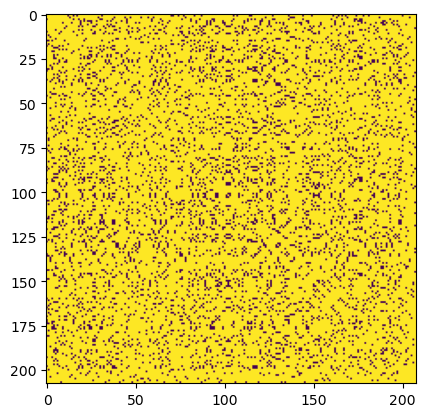

In [3]:
data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/independant_state_batches/test_batch_of_independant_states.npz")
print(data.files)

print(data["currents"].shape)
print(data["inputs"].shape)
print(data["acc_xy"].shape)
print(data["don_xy"].shape)
print(data["ele_xy"].shape)
print(data["init_energies"].shape)
print(data["acc_don_int"].shape)
print(data["acc_acc_int"].shape)
print(data["rand_energies"].shape)
print(data["rate_prefactors"].shape)
print(data["neighbours"].shape)
print(data["neighbours"][0].sum())

full_num_rates = data["neighbours"][0].shape[0]*data["neighbours"][0].shape[0]
print(data["neighbours"][0].shape[0]*data["neighbours"][0].shape[0])
print(100*data["neighbours"][0].sum() / full_num_rates, "%") 

plt.imshow(data["neighbours"][0], cmap="viridis_r")

In [65]:
def make_graph(
    currents,
    inputs,
    ele_pos,
    acc_pos,
    don_pos,
    init_energies,
    acc_don_int,
    acc_acc_int,
    rand_energies,
    rate_prefactors,
    neighbours
):
    
    graph = HeteroData()

    N_E = ele_pos.shape[0]
    N_A = acc_pos.shape[0]

    graph["electrode"].pos = torch.as_tensor(ele_pos, dtype=torch.float32)
    graph["acceptor"].pos = torch.as_tensor(acc_pos, dtype=torch.float32)

    total_acc_energies = torch.as_tensor(init_energies[:N_A], dtype=torch.float32).view(-1, 1)
    total_ele_energies = torch.as_tensor(init_energies[N_A:], dtype=torch.float32).view(-1, 1)

    acc_don_energy = torch.as_tensor(acc_don_int, dtype=torch.float32).view(-1, 1)
    acc_acc_energy = torch.as_tensor(acc_acc_int, dtype=torch.float32).view(-1, 1)
    acc_rand_energies = torch.as_tensor(rand_energies, dtype=torch.float32).view(-1, 1)

    acc_node_features = torch.cat([
        acc_don_energy,
        acc_acc_energy,
        acc_rand_energies], dim=-1)

    graph["electrode"].x = total_ele_energies
    graph["acceptor"].x = acc_node_features

    A_dense = torch.as_tensor(neighbours, dtype=torch.float32)
    R_dense = None if rate_prefactors is None else torch.as_tensor(rate_prefactors, dtype=torch.float32)

    A_dense = A_dense.clone()
    if A_dense.dtype.is_floating_point:
        A_dense.fill_diagonal_(0.0)
        mask_all = A_dense != 0
    else:
        A_dense.fill_diagonal_(0)
        mask_all = A_dense.bool()

    AA_mask = mask_all[:N_A, :N_A]
    AE_mask = mask_all[:N_A, N_A:N_A+N_E]
    EA_mask = mask_all[N_A:N_A+N_E, :N_A]
    EE_mask = mask_all[N_A:N_A+N_E, N_A:N_A+N_E]

    R_AA = R_AE = R_EA = R_EE = None
    if R_dense is not None:
        R_AA = R_dense[:N_A, :N_A]
        R_AE = R_dense[:N_A, N_A:N_A+N_E]
        R_EA = R_dense[N_A:N_A+N_E, :N_A]
        R_EE = R_dense[N_A:N_A+N_E, N_A:N_A+N_E]

    def add_edges(src_ntype, rel, dst_ntype, mask, R_block):
        
        if mask.numel() == 0:
            return
        r, c = mask.nonzero(as_tuple=True)
        if r.numel() == 0:
            return
        ei = torch.stack([r.long(), c.long()], dim=0)
        graph[(src_ntype, rel, dst_ntype)].edge_index = ei
        if R_block is not None:
            R_val = R_block[r, c].float().view(-1, 1)
            graph[(src_ntype, rel, dst_ntype)].edge_attr = R_val

    add_edges("acceptor", "A_A", "acceptor", AA_mask, R_AA)
    add_edges("acceptor", "A_E", "electrode", AE_mask, R_AE)
    add_edges("electrode", "E_A", "acceptor", EA_mask, R_EA)
    add_edges("electrode", "E_E", "electrode", EE_mask, R_EE)

    graph.y = torch.tensor([float(currents)], dtype=torch.float32)
    graph.inputs = torch.as_tensor(inputs, dtype=torch.float32).view(-1, 1)
    
    return graph

idx = 0
currents = data["currents"][idx]
inputs = data["inputs"][idx]
ele_pos = data["ele_xy"]
acc_pos = data["acc_xy"][idx]
don_pos = data["don_xy"][idx]
init_energies = data["init_energies"][idx]
acc_don_int = data["acc_don_int"][idx]
acc_acc_int = data["acc_acc_int"][idx]
rand_energies = data["rand_energies"][idx]
rate_prefactors = data["rate_prefactors"][idx]
neighbours = data["neighbours"][idx]

g = make_graph(
    currents,
    inputs,
    ele_pos, acc_pos, don_pos,
    init_energies, acc_don_int, acc_acc_int, rand_energies,
    rate_prefactors, neighbours
)

graph_list = []

for i in range(data["currents"].shape[0]):
    _g = make_graph(
            data["currents"][i],
            data["inputs"][i],
            data["ele_xy"], data["acc_xy"][i], data["don_xy"][i],
            data["init_energies"][i], data["acc_don_int"][i], data["acc_acc_int"][i], data["rand_energies"][i],
            data["rate_prefactors"][i], data["neighbours"][i]
    )

    graph_list.append(_g)  

print(len(graph_list))
        

100


In [ ]:
def sigmoid_fit(v, I_0, I_1, a, V_2):

    out = I_0 + (I_1 - I_0) / (1 + np.exp(-a*(v - V_2)))

    return out

def linear_fit(v, a, b):

    out = a*v + b

    return out

vs = np.linspace(-1.5, 1.5, 50)
n = 100
arr = np.zeros((n, n))

rows = []
for i in range(n):
    data = np.load(f"../../data/100_sweep/row_{i}.npz")
    rows.append(data["out"])
    for j in range(n):
        curve = data["out"][j]
        num_of_points = curve.shape[0]
        fit_params, cov = curve_fit(linear_fit, vs, curve)
        rmse = np.sqrt( np.mean( (curve - linear_fit(vs, fit_params[0], fit_params[1]))**2 ) )
        arr[i][j] = rmse

#flipped_arr = arr[::-1]

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(
    arr,
    extent=[0.01, 0.2,
            77, 200],
    aspect="auto",
    origin="lower",
    cmap="seismic_r"
)

xticks = np.linspace(0.01, 0.2, 5)
yticks = np.linspace(77, 200, 5)
ax.set_xticks(xticks)
ax.set_yticks(yticks)

plt.colorbar(im, ax=ax)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/100_sweep/row_18.npz'

# 2.) Truncated Normal Geometry

7.978845608028652
3.191538243211461
std_scaled: 3.191538243211461


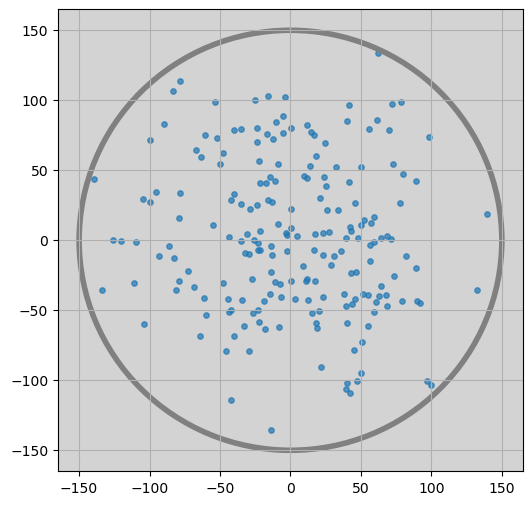

In [9]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

radius = 150.0
n_a = 200
n_d = 3
R = np.sqrt(np.pi*radius**2 / 200)
scaled_radius = radius / R
print(scaled_radius)
print(60. / R)

std_dev = radius / 2.5
std_scaled = std_dev / R
print(f"std_scaled: {std_scaled}")
cov_matrix = (std_dev ** 2) * np.eye(2)

if os.path.isfile("../../configs/acceptor_normal.txt"):
    pass
else:
    file = open("../../configs/acceptor_normal.txt", "x")

acceptor_pos = []

with open("../../configs/acceptor_normal.txt", "w") as f:
    while len(acceptor_pos) < 200:
        X = np.random.multivariate_normal(mean=np.zeros(2), cov=cov_matrix)
        if np.sqrt(X[0]**2 + X[1]**2) <= radius:
            acceptor_pos.append(X)

with open("../../configs/acceptor_normal.txt", "w") as f:
    for _pos in acceptor_pos:
        f.write(f"{_pos[0]}\t{_pos[1]}\n")

acceptors_array = np.array(acceptor_pos)

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(acceptors_array[:,0], acceptors_array[:,1], s=15., alpha=.7)
ax.grid()
ax.set_facecolor("lightgrey")    
boundary = Circle((0, 0), radius=radius, fill=False, edgecolor="gray", lw=4)
ax.add_patch(boundary)


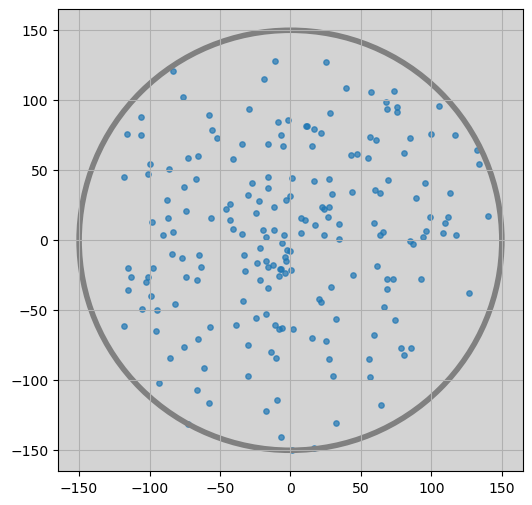

In [12]:
coordinates = []

with open("../../configs/acceptor_normal.txt", "r") as f:
    for _l in f:
        line = _l.strip().split()

        coords = np.array([float(line[0]), float(line[1])])
        coordinates.append(coords)

coordinate_array = np.array(coordinates)

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(coordinate_array[:,0], coordinate_array[:,1], s=15., alpha=.7)
ax.grid()
ax.set_facecolor("lightgrey")    
boundary = Circle((0, 0), radius=radius, fill=False, edgecolor="gray", lw=4)
ax.add_patch(boundary)


['ID', 'inputs', 'outputs']


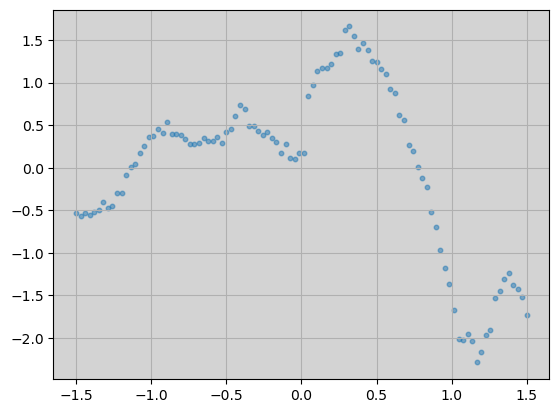

In [91]:
data = np.load("../../data/batch_10002.npz")
inputs = data["inputs"]

print(data.files)
num = len(data["outputs"][0,:])

vs = np.linspace(-1.5, 1.5, num)

plot_kwargs = {
    "s": 10.5,
    "alpha": .5,
}

fig, ax = plt.subplots()

output_mean = np.mean(data["outputs"][0, :])
output_std = np.std(data["outputs"][0, :], ddof=1)
normalized_outputs = (data["outputs"][0, :] - output_mean) / output_std

ax.scatter(vs, normalized_outputs, **plot_kwargs)
ax.grid()
ax.set_facecolor("lightgrey")

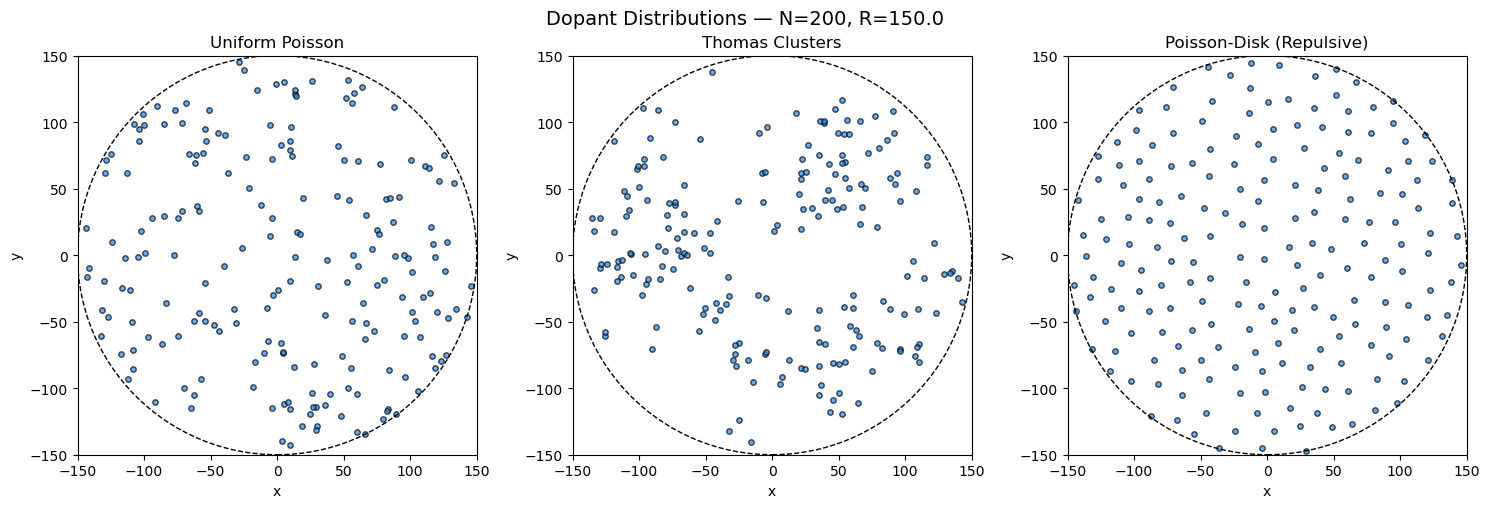

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# CONFIGURATION
# -----------------------------
R = 150.0      # disk radius
N = 200        # number of acceptors
seed = np.random.randint(0, 100000)      # reproducibility
rng = np.random.default_rng(seed)

# -----------------------------
# 1) Uniform Poisson
# -----------------------------
def sample_uniform_poisson(N, R, rng):
    # Sample polar coords
    phi = rng.uniform(0, 2*np.pi, N)
    r = R * np.sqrt(rng.uniform(0, 1, N))  # sqrt for uniform density
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    return x, y

# -----------------------------
# 2) Thomas Process (Clustering)
# -----------------------------
def sample_thomas_process(N, R, sigma=20.0, mu=10, rng=None):
    """
    Thomas (Neyman-Scott) cluster process.
    sigma = std dev of cluster radius
    mu    = mean number of offspring per parent
    """
    area = np.pi * R**2
    kappa = N / (mu * area)  # parent density
    n_parents = rng.poisson(kappa * area)

    # Sample parent locations uniformly
    phi_p = rng.uniform(0, 2*np.pi, n_parents)
    r_p = R * np.sqrt(rng.uniform(0, 1, n_parents))
    px = r_p * np.cos(phi_p)
    py = r_p * np.sin(phi_p)

    xs, ys = [], []
    while len(xs) < N:
        # Choose a random parent
        idx = rng.integers(0, n_parents)
        cx, cy = px[idx], py[idx]

        # Gaussian displacement
        dx = rng.normal(0, sigma)
        dy = rng.normal(0, sigma)

        x = cx + dx
        y = cy + dy

        # Keep only if inside disk
        if x**2 + y**2 <= R**2:
            xs.append(x)
            ys.append(y)

    return np.array(xs), np.array(ys)

# -----------------------------
# 3) Hard-Core Poisson Disk (Repulsion)
# -----------------------------
def sample_poisson_disk(N, R, h=15.0, max_tries=10000, rng=None):
    """Simple dart-throwing Poisson-disk sampling."""
    xs, ys = [], []
    tries = 0
    h2 = h**2
    while len(xs) < N and tries < max_tries:
        tries += 1
        phi = rng.uniform(0, 2*np.pi)
        r = R * np.sqrt(rng.uniform(0, 1))
        x = r * np.cos(phi)
        y = r * np.sin(phi)

        # Check min distance constraint
        ok = True
        for xx, yy in zip(xs, ys):
            if (x-xx)**2 + (y-yy)**2 < h2:
                ok = False
                break
        if ok:
            xs.append(x)
            ys.append(y)
    return np.array(xs), np.array(ys)

# -----------------------------
# Generate three distributions
# -----------------------------
x_uni, y_uni = sample_uniform_poisson(N, R, rng)
x_tho, y_tho = sample_thomas_process(N, R, sigma=20.0, mu=10, rng=rng)
x_rep, y_rep = sample_poisson_disk(N, R, h=15.0, rng=rng)

# -----------------------------
# Visualization
# -----------------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Uniform Poisson", "Thomas Clusters", "Poisson-Disk (Repulsive)"]

for ax, (x, y, title) in zip(axs, [(x_uni, y_uni, titles[0]),
                                  (x_tho, y_tho, titles[1]),
                                  (x_rep, y_rep, titles[2])]):
    ax.set_aspect("equal")
    ax.set_xlim(-R, R)
    ax.set_ylim(-R, R)
    ax.scatter(x, y, s=15, color="dodgerblue", alpha=0.7, edgecolor="k")
    circle = plt.Circle((0, 0), R, fill=False, color="black", linestyle="--")
    ax.add_artist(circle)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle(f"Dopant Distributions — N={N}, R={R}", fontsize=14)
plt.tight_layout()
plt.show()
